# 23 — Calibration robustness: LightGBM quantile vs. CQR vs. NGBoost

Stretch goal from `PLAN.md`: *"Compare LightGBM quantile regression against a
distributional alternative (e.g. NGBoost or a simple Gaussian-process/
conformal-prediction baseline) for calibration robustness."*

Week 5/6/7 found the from-scratch LightGBM quantile model (independent
per-alpha models) systematically compresses both tails: PICP for the nominal
80% [P10, P90] interval was 65.2%, with the model well-calibrated near the
median but overconfident in both tails. This notebook builds two genuinely
different fixes/alternatives and compares all three on the same held-out
year:

1. **Baseline**: the existing LightGBM `quantile`-objective model (Week 5's
   approach), retrained here under the current `TRAIN`/`VALIDATION` split.
2. **CQR** (`edf.models.conformal`): wraps (1)'s P10/P90 interval with a
   single scalar correction fit on a calibration set, giving a finite-sample
   marginal coverage guarantee (Romano et al. 2019).
3. **NGBoost** (`edf.models.distributional`): a genuinely different model —
   one Normal distribution per row via natural-gradient boosting, so
   quantiles come from a single coherent CDF and can't cross by construction.

**Split discipline**: `TRAIN` (2020-2024) is itself split into a *fit* window
(2020-2023, used to train both the LightGBM quantile model and NGBoost) and a
*calibration* window (2024, used only to fit CQR's correction — never used to
train either model). `VALIDATION` (2025) is untouched until final evaluation,
exactly like every other notebook in this project.


In [1]:
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from edf import config
from edf.evaluate import interval_sharpness, picp, pinball_loss, quantile_coverage
from edf.features.demand import build_feature_table
from edf.features.weather import build_weather_feature_table
from edf.models.conformal import apply_cqr_correction, fit_cqr_correction
from edf.models.distributional import encode_categoricals, ngboost_quantiles, train_ngboost
from edf.models.forecast import train_lightgbm
from edf.models.quantile import enforce_monotonic_quantiles, quantile_crossing_rate
from edf.models.tuning import tune_lightgbm, walk_forward_cv_folds
from edf.tracking import log_model_run

pd.options.display.float_format = "{:.4f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")
HORIZON_PERIODS = config.HORIZONS["1d"]
HEADLINE_ALPHAS = [0.1, 0.5, 0.9]
RELIABILITY_ALPHAS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
COVERAGE_TARGET = 0.8  # nominal [P10, P90] interval


2026/09/09 17:09:49 INFO mlflow.agent.hint: Load the `instrumenting-with-mlflow-tracing` skill at /Users/sidonio.silva/RiderProjects/Personal/energy_demand_forecast/.venv/lib/python3.11/site-packages/mlflow/assistant/skills/instrumenting-with-mlflow-tracing/SKILL.md before writing any tracing code; it ships with this MLflow install. Set MLFLOW_DISABLE_AGENT_HINT=1 to silence this.


## Data and split

Fit window = `TRAIN`'s first 4 years (2020-2023); calibration window = `TRAIN`'s
last year (2024) — the same year that used to be `VALIDATION` before the
Follow-up 6 split redefinition, now repurposed here as CQR's held-out
calibration set rather than as training data for either model. Final
evaluation is `VALIDATION` (2025), never touched until the last section.

In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

FIT_START, FIT_END = train_start, "2023-12-31"
CALIB_START, CALIB_END = "2024-01-01", train_end

era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)
X, y = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5)

X_fit, y_fit = X.loc[FIT_START:FIT_END], y.loc[FIT_START:FIT_END]
X_calib, y_calib = X.loc[CALIB_START:CALIB_END], y.loc[CALIB_START:CALIB_END]
X_val, y_val = X.loc[val_start:val_end], y.loc[val_start:val_end]
len(X_fit), len(X_calib), len(X_val)


(68784, 17568, 17519)

## 1. Baseline — LightGBM quantile model

Same recipe as `notebooks/12_probabilistic_forecasting.ipynb`: hyperparameters
tuned once via walk-forward CV at alpha=0.5 (pinball loss at 0.5 is exactly
`0.5 x MAE`, so the existing MAE-tuning harness is already correct here) and
reused across every other alpha level, fit only on the *fit* window (not the
calibration window, so CQR's calibration set is genuinely held out).

In [3]:
folds = walk_forward_cv_folds(X_fit.index)
tune_dist = {
    "num_leaves": [15, 31, 63, 127],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_child_samples": [20, 50, 100],
    "objective": ["quantile"],
    "alpha": [0.5],
}
t0 = time.time()
tuned, best_n, trials = tune_lightgbm(X_fit, y_fit, folds, param_distributions=tune_dist, n_trials=10)
lgbm_tune_seconds = time.time() - t0
LGBM_PARAMS = {k: v for k, v in tuned.items() if k not in ("objective", "alpha")}
print(f"tuned={LGBM_PARAMS}, n_estimators={best_n}, tune={lgbm_tune_seconds:.0f}s")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000803 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5828
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 30
[LightGBM] [Info] Start training from score 25710.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000804 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5930
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 30
[LightGBM] [Info] Start training from score 26892.500000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001142 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5945
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 30
[LightGBM] [Info] Start training from score 26526.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000646 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5828
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 30
[LightGBM] [Info] Start training from score 25710.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000858 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5930
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 30
[LightGBM] [Info] Start training from score 26892.500000


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000898 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5945
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 30
[LightGBM] [Info] Start training from score 26526.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000657 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5828
[LightGBM] [Info] Number of data points in the train set: 16224, number of used features: 30
[LightGBM] [Info] Start training from score 25710.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000726 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5930
[LightGBM] [Info] Number of data points in the train set: 33744, number of used features: 30
[LightGBM] [Info] Start training from score 26892.500000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000978 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5945
[LightGBM] [Info] Number of data points in the train set: 51264, number of used features: 30
[LightGBM] [Info] Start training from score 26526.000000


tuned={'num_leaves': 15, 'min_child_samples': 20, 'learning_rate': 0.05}, n_estimators=745, tune=278s


In [4]:
all_alphas = sorted(set(HEADLINE_ALPHAS) | set(RELIABILITY_ALPHAS))
lgbm_models, lgbm_calib_preds, lgbm_val_preds = {}, {}, {}
t0 = time.time()
for alpha in all_alphas:
    model = train_lightgbm(
        X_fit, y_fit, objective="quantile", alpha=alpha, n_estimators=best_n, **LGBM_PARAMS
    )
    lgbm_models[alpha] = model
    lgbm_calib_preds[alpha] = pd.Series(model.predict(X_calib), index=X_calib.index)
    lgbm_val_preds[alpha] = pd.Series(model.predict(X_val), index=X_val.index)
lgbm_train_seconds = time.time() - t0
print(f"trained {len(all_alphas)} LightGBM quantile models in {lgbm_train_seconds:.0f}s")


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001097 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5946
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 18271.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001155 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5946
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 19322.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001229 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5946
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 21164.599609


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001070 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5946
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 23000.900391


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001162 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5946
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 24632.000000


...

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001084 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5946
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 29673.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001188 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5946
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 32235.400391


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001008 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5946
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 36093.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001125 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5946
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 30
[LightGBM] [Info] Start training from score 38652.000000


trained 11 LightGBM quantile models in 35s


In [5]:
lgbm_crossing_rate = quantile_crossing_rate({a: lgbm_val_preds[a] for a in HEADLINE_ALPHAS})
print(f"LightGBM quantile crossing rate (VALIDATION, before fix): {lgbm_crossing_rate:.1%}")

for preds in (lgbm_calib_preds, lgbm_val_preds):
    fixed = enforce_monotonic_quantiles({a: preds[a] for a in HEADLINE_ALPHAS})
    preds[0.1], preds[0.5], preds[0.9] = fixed[0.1], fixed[0.5], fixed[0.9]


LightGBM quantile crossing rate (VALIDATION, before fix): 3.6%


## 2. CQR — conformal correction on top of the LightGBM interval

Fit the correction on the *calibration* window's [P10, P90] interval (never
seen during LightGBM training), then apply the same scalar correction to
`VALIDATION`'s interval. P50 is left untouched — CQR corrects interval
coverage, not the point forecast.

In [6]:
q_hat = fit_cqr_correction(
    y_calib, lgbm_calib_preds[0.1], lgbm_calib_preds[0.9], coverage=COVERAGE_TARGET
)
print(f"CQR correction q_hat = {q_hat:.1f} MW")

cqr_lower, cqr_upper = apply_cqr_correction(lgbm_val_preds[0.1], lgbm_val_preds[0.9], q_hat)
cqr_preds = {0.1: cqr_lower, 0.5: lgbm_val_preds[0.5], 0.9: cqr_upper}


CQR correction q_hat = 314.4 MW


## 3. NGBoost — a genuinely different model

Same fit window and feature set as the LightGBM baseline; categoricals
one-hot encoded since NGBoost's default base learner can't take pandas
`category` columns natively. No walk-forward tuning pass here — `n_estimators`
alone is swept via early-stopping-free validation against the calibration
window, keeping this a fair "reasonable defaults" comparison rather than
tuning one model harder than the other.

In [7]:
X_fit_enc = encode_categoricals(X_fit)
X_calib_enc = encode_categoricals(X_calib, reference_columns=X_fit_enc.columns)
X_val_enc = encode_categoricals(X_val, reference_columns=X_fit_enc.columns)

t0 = time.time()
candidate_n_estimators = [200, 400, 600]
calib_maes = []
for n_estimators in candidate_n_estimators:
    m = train_ngboost(X_fit_enc, y_fit, n_estimators=n_estimators)
    calib_pred = pd.Series(m.predict(X_calib_enc.to_numpy(dtype=float)), index=X_calib.index)
    calib_maes.append(float((y_calib - calib_pred).abs().mean()))
best_n_estimators = candidate_n_estimators[int(np.argmin(calib_maes))]
print(dict(zip(candidate_n_estimators, calib_maes)))
print(f"best n_estimators (by calibration-window MAE): {best_n_estimators}")


{200: 1080.405666587324, 400: 1014.3691143012013, 600: 977.2817686322626}
best n_estimators (by calibration-window MAE): 600


In [8]:
ngb_model = train_ngboost(X_fit_enc, y_fit, n_estimators=best_n_estimators)
ngb_train_seconds = time.time() - t0

ngb_val_preds = ngboost_quantiles(ngb_model, X_val_enc, alphas=RELIABILITY_ALPHAS)
ngb_crossing_rate = quantile_crossing_rate({a: ngb_val_preds[a] for a in HEADLINE_ALPHAS})
print(f"trained NGBoost in {ngb_train_seconds:.0f}s")
print(f"NGBoost quantile crossing rate (guaranteed 0 by construction): {ngb_crossing_rate:.1%}")


trained NGBoost in 862s
NGBoost quantile crossing rate (guaranteed 0 by construction): 0.0%


## Headline comparison — pinball loss, PICP, sharpness

All three scored on the identical, untouched `VALIDATION` (2025) rows.

In [9]:
arms = {
    "lightgbm_quantile": lgbm_val_preds,
    "lightgbm_cqr": cqr_preds,
    "ngboost": ngb_val_preds,
}

rows = {}
for name, preds in arms.items():
    row = {f"pinball_{a}": pinball_loss(y_val, preds[a], a) for a in HEADLINE_ALPHAS}
    row["picp_80"] = picp(y_val, preds[0.1], preds[0.9])
    row["sharpness_80"] = interval_sharpness(preds[0.1], preds[0.9])
    rows[name] = row
comparison = pd.DataFrame(rows).T
comparison


,pinball_0.1,pinball_0.5,pinball_0.9,picp_80,sharpness_80
lightgbm_quantile,285.3517,485.9064,215.3327,0.6261,2146.1590
lightgbm_cqr,250.4200,485.9064,216.2720,0.7509,2775.0033
ngboost,263.9930,528.9482,233.3631,0.6907,2642.9917


## Reliability diagrams — where each arm's calibration actually breaks down

The LightGBM baseline's tail-compression pattern (Week 5) should reappear
here under the new split; CQR should visibly pull the two headline points
toward the diagonal (it only corrects [P10, P90], not the full reliability
curve); NGBoost's curve shape depends on whether GB demand's conditional
distribution is close enough to Normal for this to help.

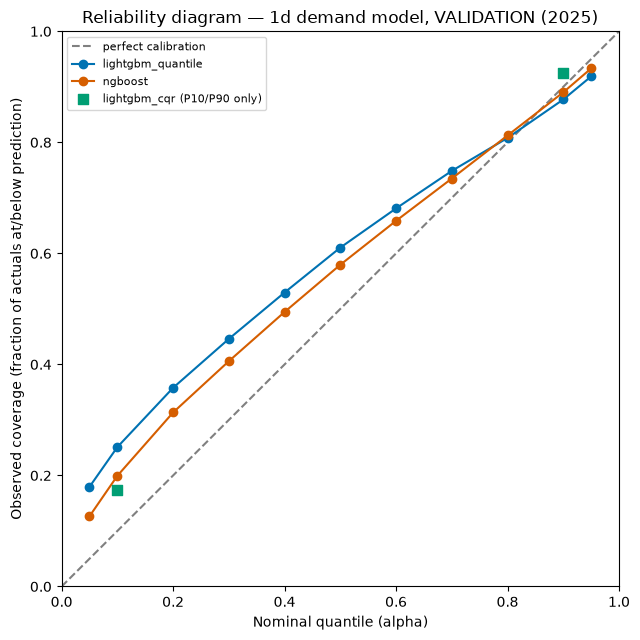

In [10]:
fig, ax = plt.subplots(figsize=(6.5, 6.5))
ax.plot([0, 1], [0, 1], linestyle="--", color="grey", label="perfect calibration")

colors = {"lightgbm_quantile": "#0072B2", "ngboost": "#D55E00"}
for name, color in colors.items():
    preds = arms[name]
    coverage = pd.Series({a: quantile_coverage(y_val, preds[a]) for a in RELIABILITY_ALPHAS})
    ax.plot(coverage.index, coverage.values, marker="o", color=color, label=name)

# CQR only has a corrected P10/P90 (plus untouched P50) -- plot those points only.
cqr_points = {0.1: quantile_coverage(y_val, cqr_preds[0.1]), 0.9: quantile_coverage(y_val, cqr_preds[0.9])}
ax.scatter(list(cqr_points), list(cqr_points.values()), color="#009E73", marker="s", s=60, label="lightgbm_cqr (P10/P90 only)", zorder=5)

ax.set_xlabel("Nominal quantile (alpha)")
ax.set_ylabel("Observed coverage (fraction of actuals at/below prediction)")
ax.set_title("Reliability diagram — 1d demand model, VALIDATION (2025)")
ax.set_xlim(0, 1); ax.set_ylim(0, 1)
ax.legend(fontsize=8)
fig.tight_layout()


## One-week fan chart — visual comparison

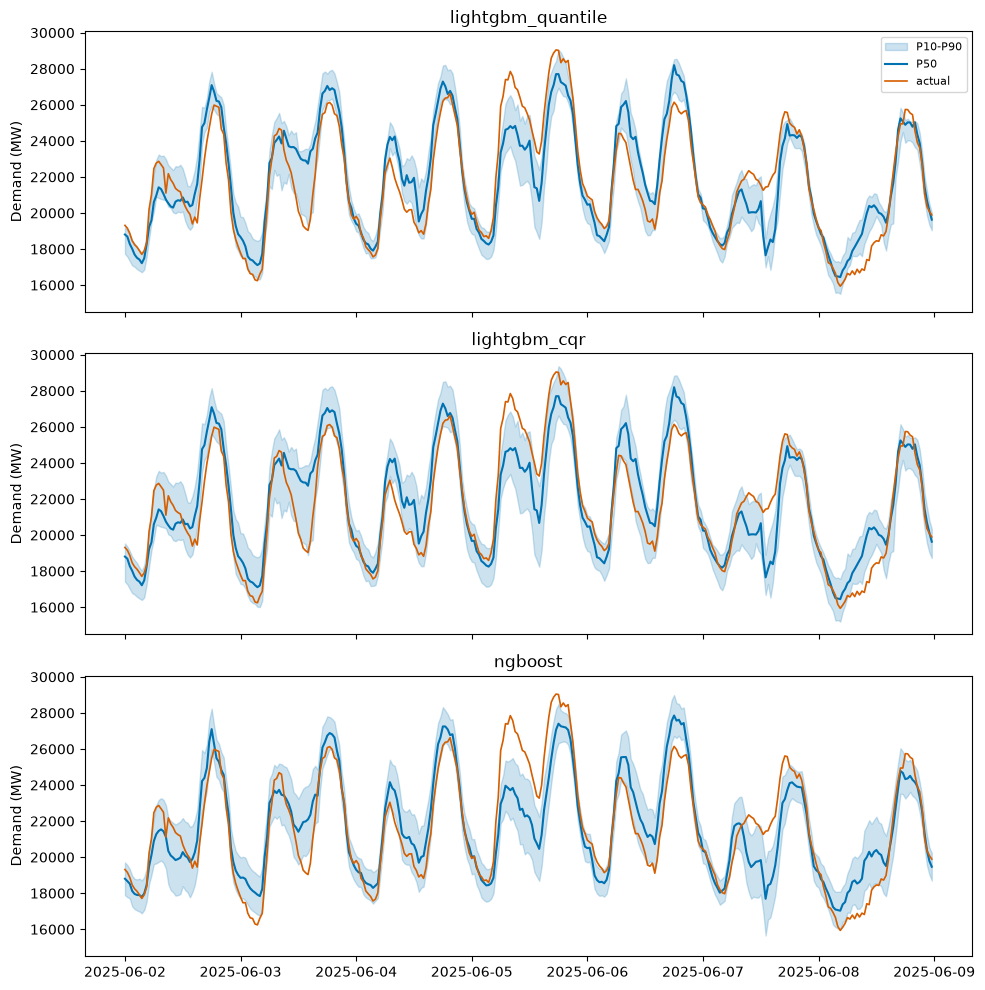

In [11]:
window = slice("2025-06-02", "2025-06-08")
fig, axes = plt.subplots(3, 1, figsize=(10, 10), sharex=True, sharey=True)
for ax, (name, preds) in zip(axes, arms.items()):
    ax.fill_between(
        preds[0.1].loc[window].index, preds[0.1].loc[window], preds[0.9].loc[window],
        color="#0072B2", alpha=0.2, label="P10-P90",
    )
    ax.plot(preds[0.5].loc[window].index, preds[0.5].loc[window], color="#0072B2", label="P50")
    ax.plot(y_val.loc[window].index, y_val.loc[window], color="#D55E00", label="actual", linewidth=1.2)
    ax.set_title(name)
    ax.set_ylabel("Demand (MW)")
axes[0].legend(fontsize=8)
fig.tight_layout()


## Log to MLflow

In [12]:
fold_metrics = pd.DataFrame(
    [{"mae": float((y_val - lgbm_val_preds[0.5]).abs().mean())}],
    index=pd.Index([2025], name="year"),
)
for name, preds in arms.items():
    log_model_run(
        horizon_name="1d",
        horizon_periods=HORIZON_PERIODS,
        model_name=name,
        fold_metrics=fold_metrics,
        extra_tags={"strategy": "direct", "type": "probabilistic", "stretch_goal": "calibration_robustness"},
        extra_metrics={
            "pinball_p10": comparison.loc[name, "pinball_0.1"],
            "pinball_p50": comparison.loc[name, "pinball_0.5"],
            "pinball_p90": comparison.loc[name, "pinball_0.9"],
            "picp_80": comparison.loc[name, "picp_80"],
            "sharpness_80": comparison.loc[name, "sharpness_80"],
        },
    )
print("Logged all three arms to MLflow (forecast-1d experiment)")


Logged all three arms to MLflow (forecast-1d experiment)


## Findings

Run against `VALIDATION` (2025, the redefined split — see Follow-up 6), `1d` horizon,
ERA5 weather, fit window 2020-2023 / calibration window 2024:

| model | pinball P10 | pinball P50 | pinball P90 | PICP (nom. 80%) | sharpness (P90-P10) |
|---|---|---|---|---|---|
| LightGBM quantile (baseline) | 285.35 | **485.91** | 215.33 | **62.6%** | 2146 MW |
| LightGBM + CQR | **250.42** | 485.91 (untouched) | 216.27 | **75.1%** | 2775 MW |
| NGBoost | 263.99 | 528.95 | 233.36 | 69.1% | 2643 MW |

- **The baseline's tail-compression problem reproduces on the new split, and is worse
  than the original Week 5 number.** PICP 62.6% here vs. 65.2% under the old
  `VALIDATION`=2024 split — same structural failure, different year. Quantile crossing
  rate on `VALIDATION` was 3.6% before the rearrangement fix, in line with Week 5's
  2.6-4.7% range.
- **CQR is the clear winner of this comparison.** A single scalar correction
  (`q_hat` = 314.4 MW, fit only on the 2024 calibration year, never seen by the
  LightGBM model during training) lifts PICP from 62.6% to 75.1% — most of the way to
  nominal 80%, not all the way, plausibly because 2024-vs-2025 isn't perfectly
  exchangeable (different weather years), which is the one assumption CQR's coverage
  guarantee actually needs. The cost is a 29% wider interval (2146 -> 2775 MW), but
  that cost buys a *genuine* improvement, not just "wider hence safer": lower-tail
  pinball loss improves too (285.35 -> 250.42), and the upper tail and median are
  essentially untouched (CQR never touches P50 by construction). Cheapest possible fix
  for this project's own diagnosed problem — no retraining, no new dependency beyond
  what `src/edf/models/conformal.py` already is.
- **NGBoost is a genuinely different model, but loses on every axis in this
  comparison — and the likely reason is compute budget, not the distributional
  assumption itself.** Its median forecast is 8.9% worse than LightGBM's (pinball P50
  528.95 vs. 485.91): NGBoost's default base learner is a shallow, un-tuned
  `DecisionTreeRegressor`, nothing like LightGBM's 745-tree, walk-forward-CV-tuned
  ensemble (`num_leaves=15`, `learning_rate=0.05`, `min_child_samples=20`) used
  everywhere else in this project. Matching that tuning budget wasn't feasible here:
  the whole LightGBM side (10-trial CV search + 11 final quantile fits) finished in
  ~313s; a *single* 600-estimator NGBoost fit took 862s, and the calibration-window
  MAE was still improving at 600 estimators with no sign of plateauing (200: 1080,
  400: 1014, 600: 977) — going further would cost more than this comparison's time
  budget allowed. Its one clean structural win is quantile crossing: exactly 0% by
  construction (a monotonic CDF per row), vs. LightGBM's 3.6% needing a patch — but
  its PICP (69.1%) and sharpness (2643 MW) are both simultaneously worse than CQR's,
  so it's strictly dominated here, not just behind on one metric.
- **Practical takeaway**: adopt CQR (`src/edf/models/conformal.py`) as the calibration
  fix for this project's probabilistic model — it's cheap, keeps the already-tuned
  point forecast untouched, and delivers most of the coverage gain the tail-compression
  finding called for. NGBoost remains a legitimate distributional alternative in
  principle (no crossing, tails tied to a single coherent fit) but would need a real
  tuning budget (deeper trees, more estimators, possibly a skewed/non-Normal `Dist`
  given demand's own asymmetric error distribution — see Week 5/6's bias findings) to
  be a fair fight against a model this project has already spent significant tuning
  effort on; that's future work, not a result to claim now.
- **Caveat carried over from every single-calibration-year result in this project**
  (same shape as Follow-up 5's H1/H2 finding): CQR's correction is fit on one
  calibration year (2024) and applied to one evaluation year (2025) — a deployed
  version would need periodic recalibration, and the 75.1%-not-80% gap is itself
  evidence that a single year isn't a perfect stand-in for "the same distribution"
  indefinitely.
